In [12]:
%autoreload 2

In [11]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 5})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_33704\3014778103.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [40]:
path =r"C:\Data\Imaging//260425_overlap//All_behavior//"
all_df = []
all_saccade_df = []
fishlist = [
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]
for f in fishlist:
    bout_df = pd.read_csv(f + '//Tail//tail_bout_df_classified.csv', index_col=0)
    bout_df.loc[:, 'tail_angle_norm'] = np.subtract(bout_df.tail_angle,bout_df[bout_df.tail_realstimuli == 'stationary'].tail_angle.mean())
    saccade_df = pd.read_csv(f + '//eye//eye_saccade_df_classified.csv', index_col = 0)
    bout_df.loc[:, "fish_id"] = f
    bout_df.loc[:, 'real_fish_id'] = str(f).split("Imaging")[1].split("_")[0]+str(f).split("Imaging")[1].split("_")[1]
    saccade_df.loc[:, 'fish_id'] = f
    saccade_df.loc[:, 'real_fish_id'] = str(f).split("Imaging")[1].split("_")[0]+str(f).split("Imaging")[1].split("_")[1]
    all_df.append(bout_df)
    all_saccade_df.append(saccade_df)
    

all_df = pd.concat(all_df).reset_index(drop = True)
all_saccade_df = pd.concat(all_saccade_df).reset_index(drop = True)

stimulus_df = Gafftopsail(fishlist[0] + '//', filelist = ['stimulus']).stimulus_df
#stimulus_df =Coelacanth(f + '//', filelist = ['stimulus']).stimulus_df
stimulus_df.loc[:, "stim_name"] = [str(s) for s in stimulus_df.stim_name]

#for overlap fishes
omr_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' not in i) and ('pause' not in i)]
dot_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' in i) and ('pause' not in i)]
overlap_stim = [i for i in stimulus_df.stim_name.unique() if ('dot' in i) & ('[' in i)]
stimlists =[[str(['dot_l', 'forward']), str(['dot_l', 'left']), str(['dot_l', 'right']), str(['dot_l', 'backward']), str(['dot_r', 'forward']), str(['dot_r', 'left']), str(['dot_r', 'right']), str(['dot_r', 'backward'])], ['dot_l', 'dot_r'], ['forward', 'left', 'right', 'backward']]



plotting 2p setup dot position
plotting 2p setup dot position


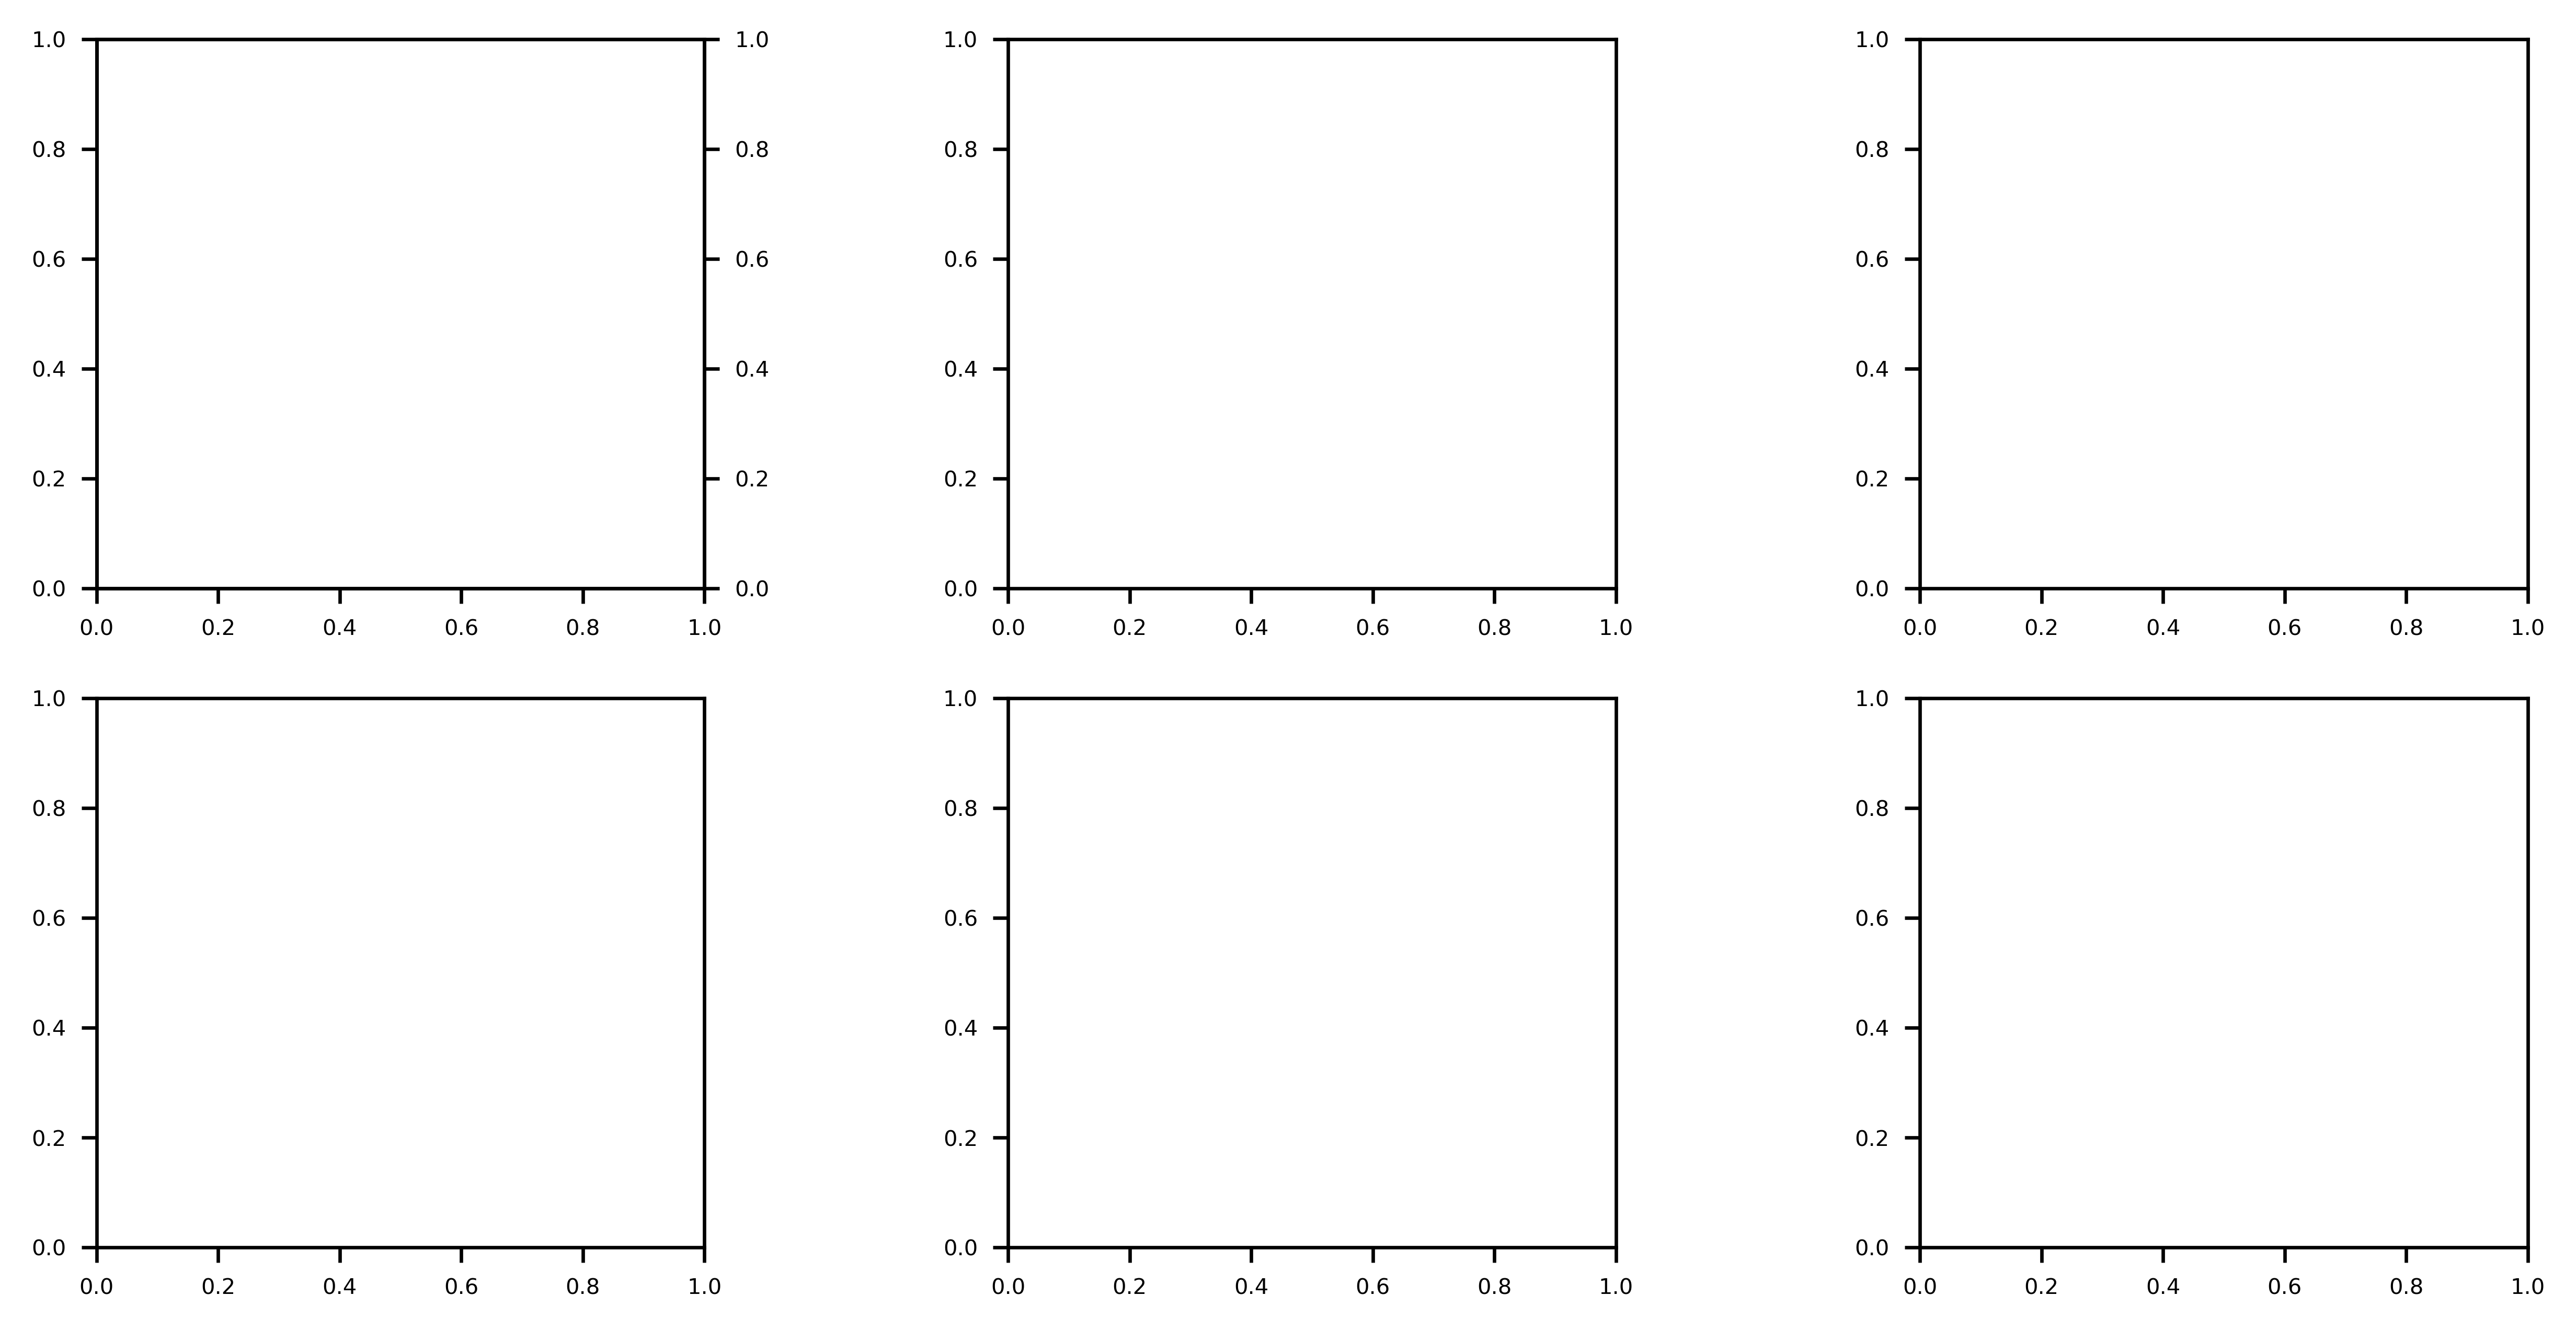

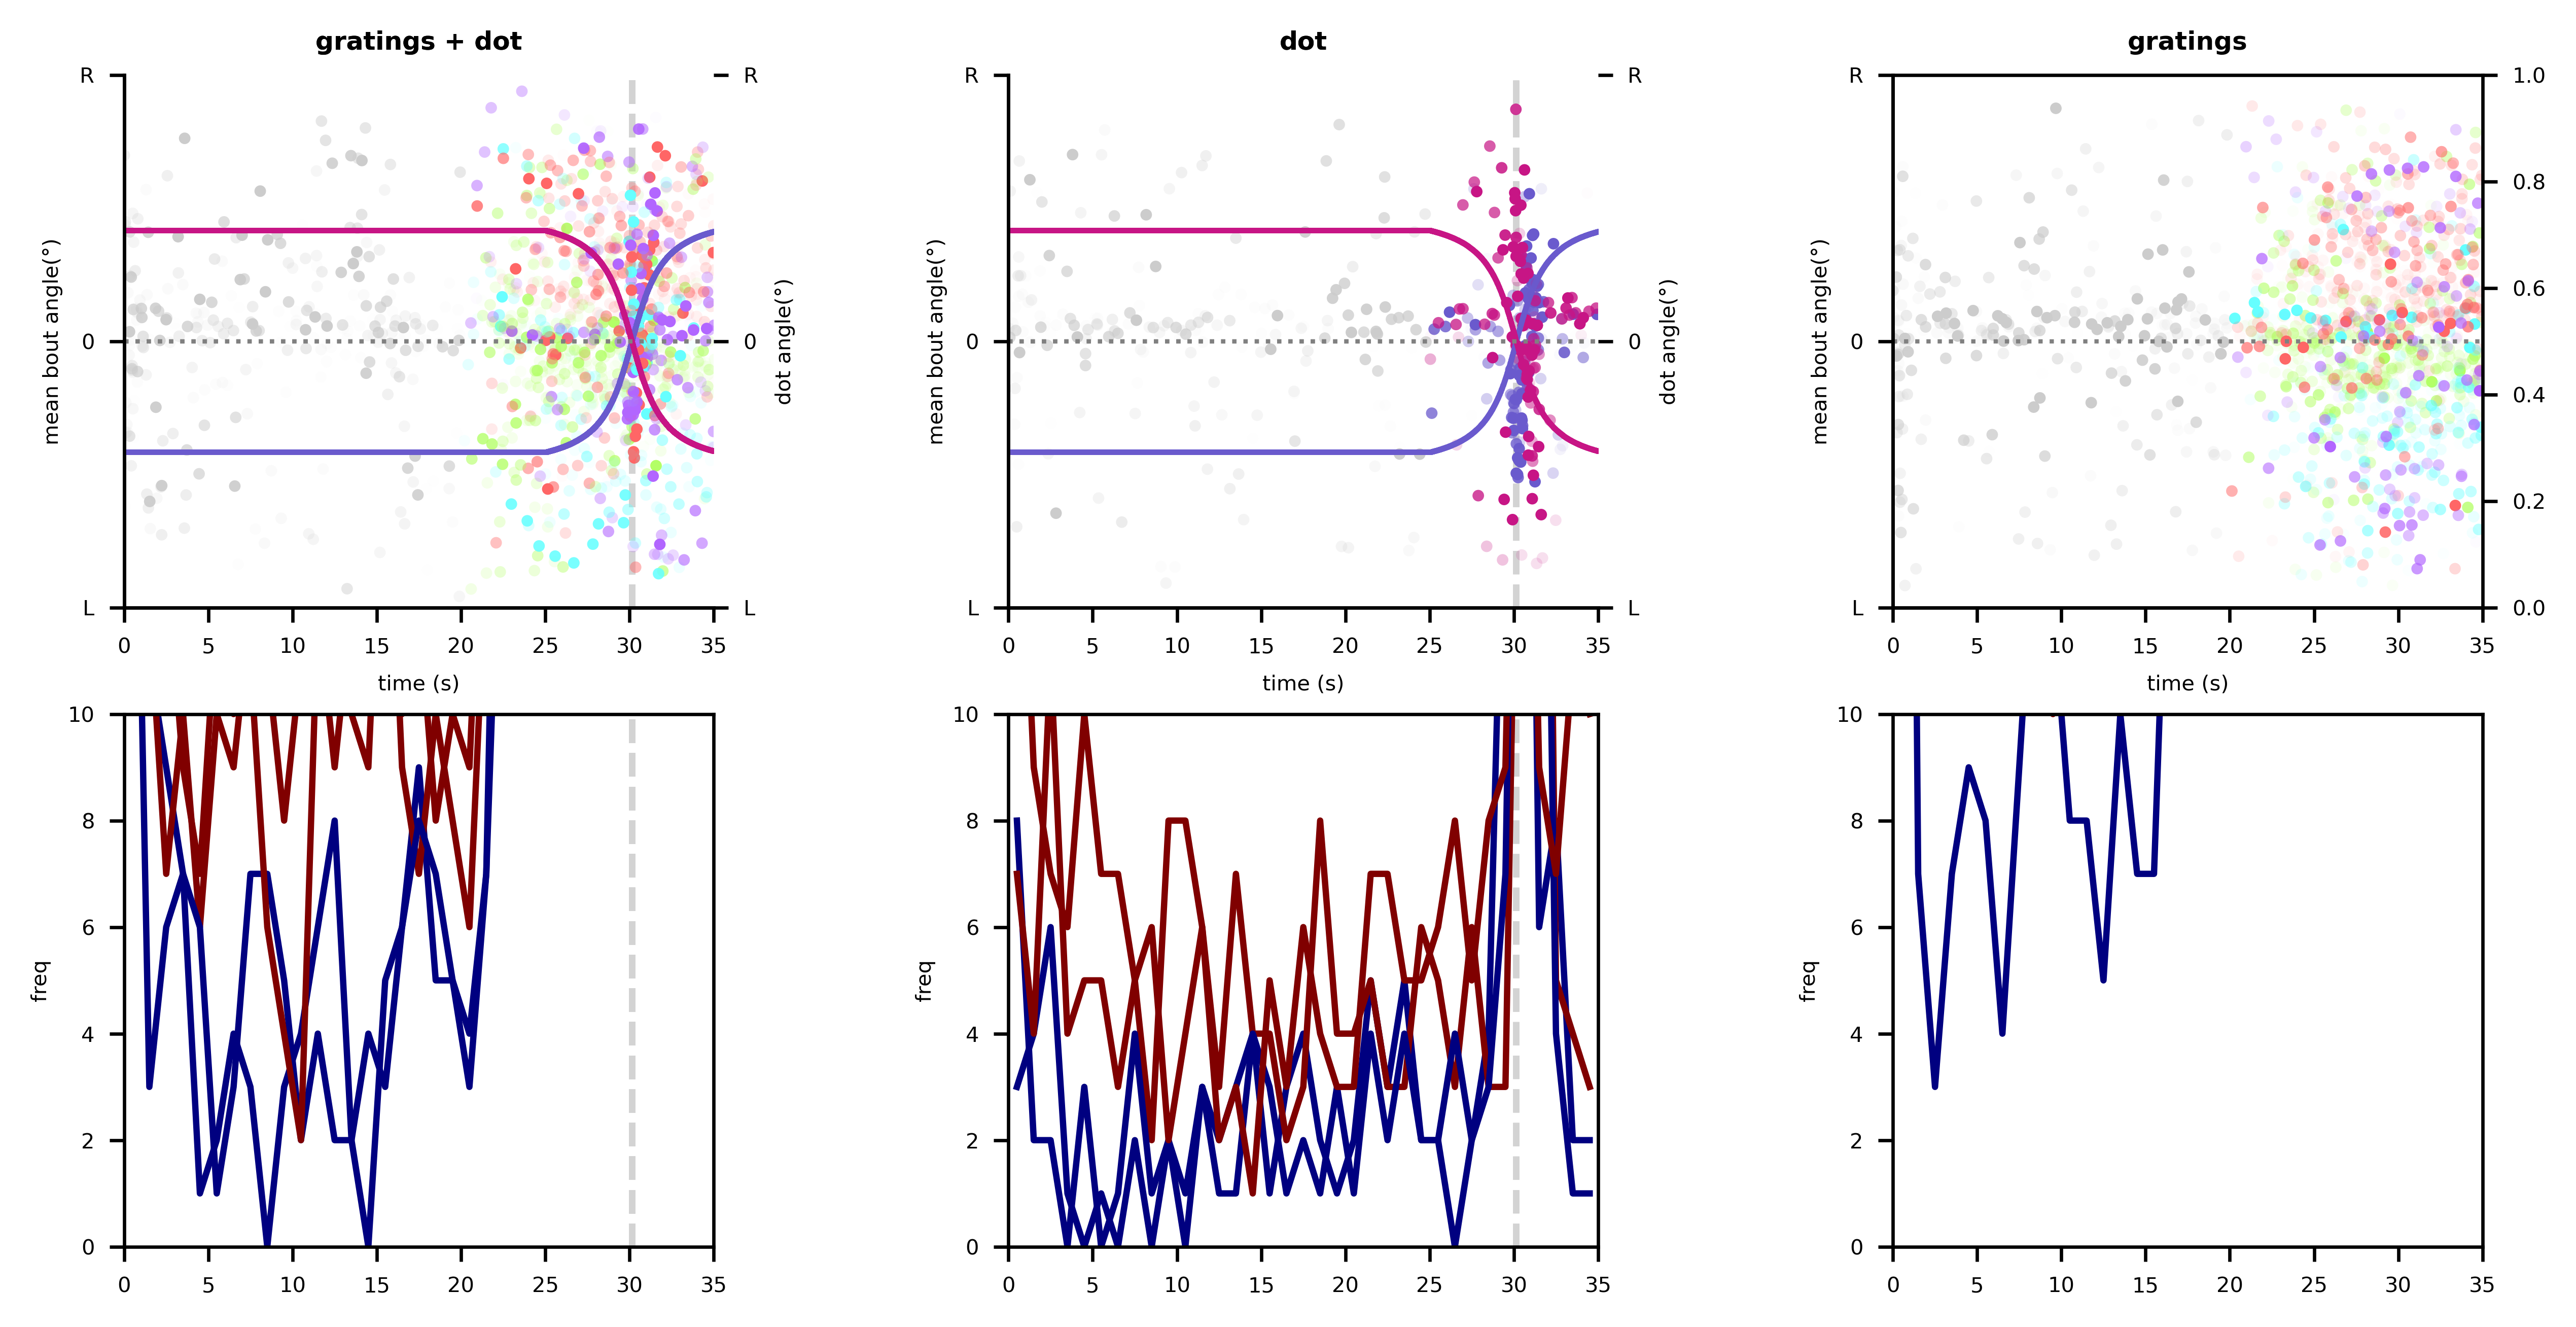

In [5]:
fig = bhfd.plot_bouttime_distribution(None, stimlists, s = 30, group = True, tail_bout_df = all_df, stimulus_df = stimulus_df)
fig.savefig(path+"//individual_bout_angle_acrosstime_overlaps.svg")
plt.show()
plt.close()

plotting 2p setup dot position
plotting 2p setup dot position


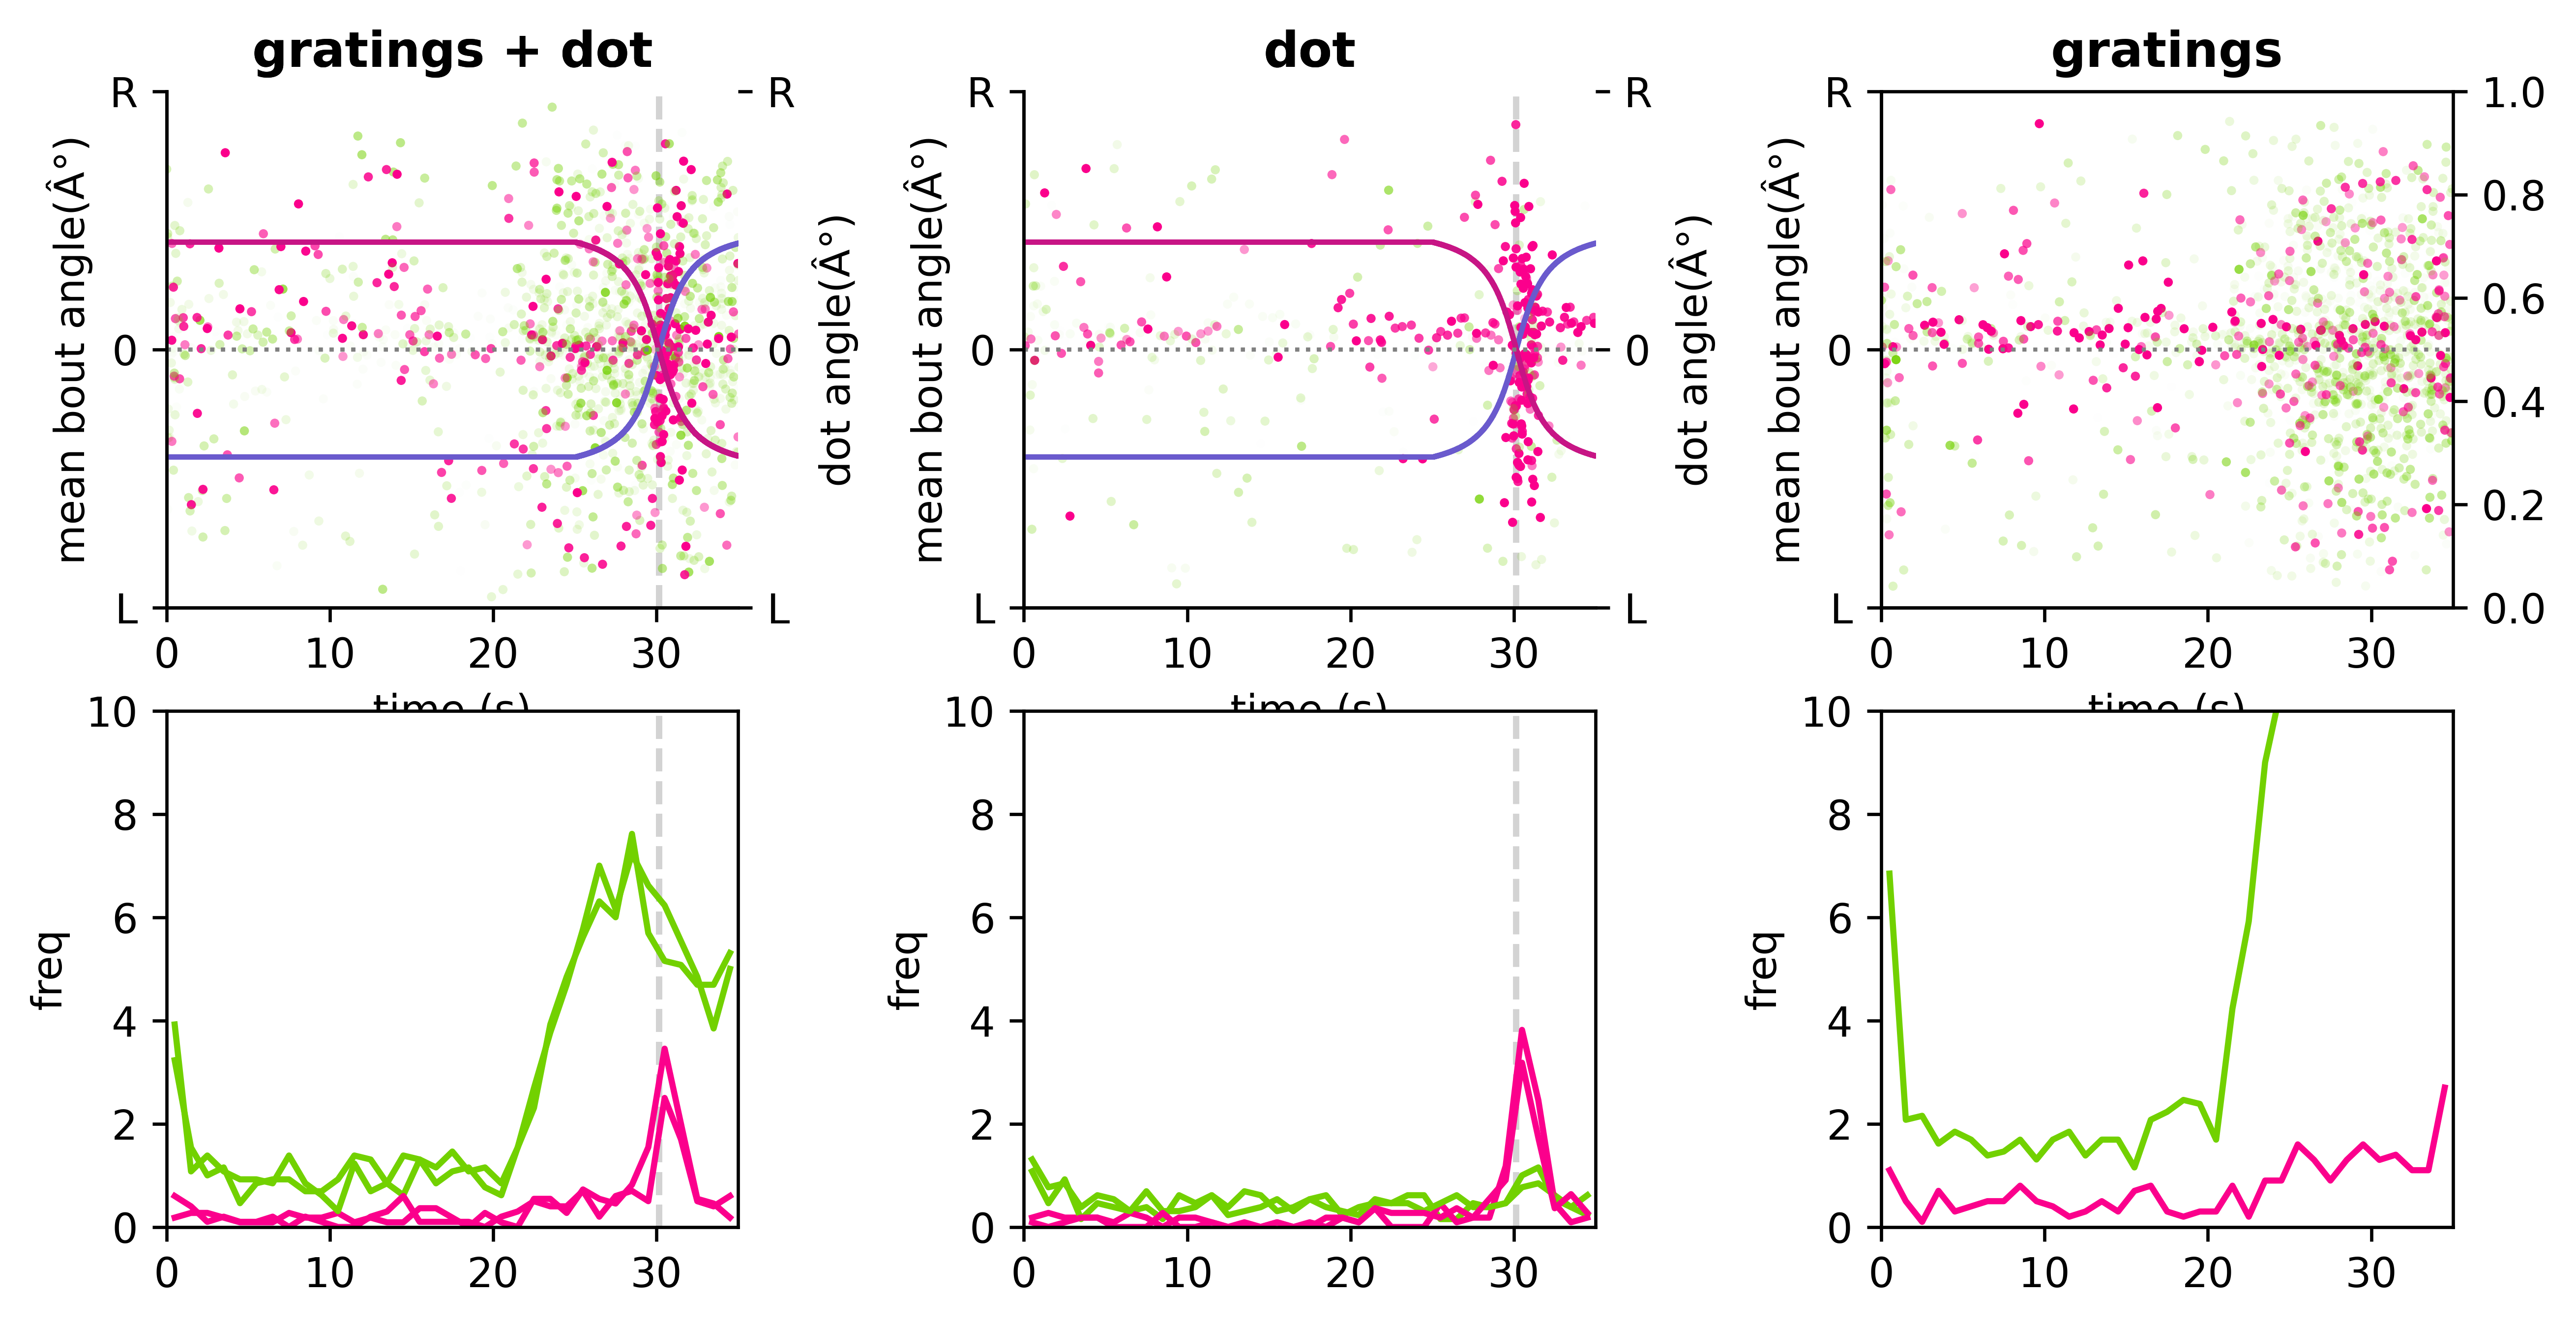

In [42]:
fig = bhfd.plot_bouttime_distribution(None, stimlists, s = 20, group = True, tail_bout_df = all_df, stimulus_df = stimulus_df, classified = True)
fig.savefig(path+"//individual_bout_angle_acrosstime_classified.svg")
plt.show()
plt.close()

plotting 2p setup dot position


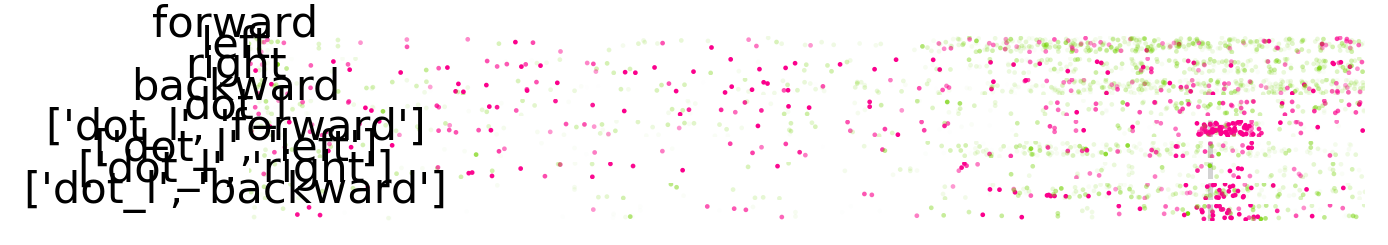

plotting 2p setup dot position


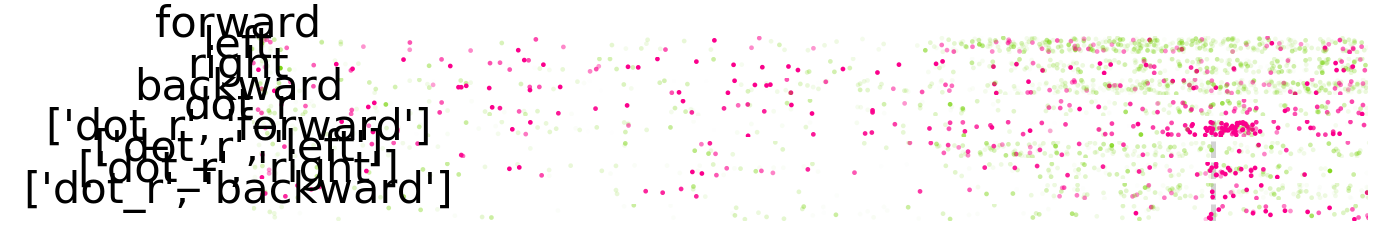

plotting 2p setup dot position


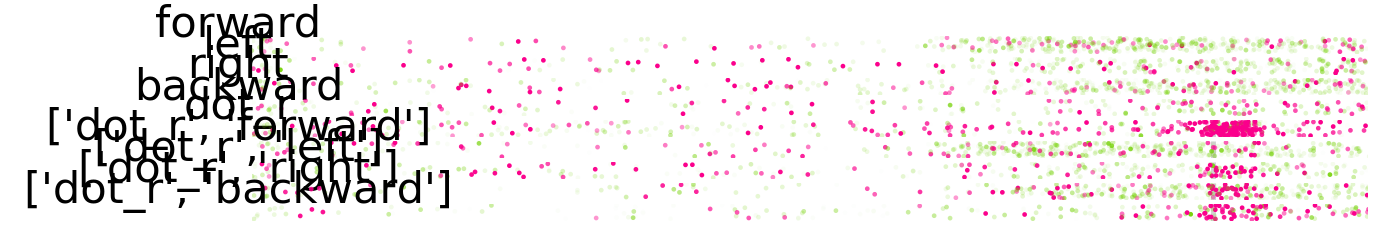

In [36]:
stim_list = ['forward', 'left', 'right', 'backward', 'dot_l', str(['dot_l', 'forward']), str(['dot_l', 'left']),
             str(['dot_l', 'right']), str(['dot_l', 'backward'])]
bhfd.plot_simple_nearestsaccade(all_df, stim_list, 'slateblue', stimulus_df, classified=True)
plt.savefig(path + 'simple_bout_nearestsaccade_dotl.svg')
plt.show()
plt.close()

stim_list = ['forward', 'left', 'right', 'backward', 'dot_r', str(['dot_r', 'forward']), str(['dot_r', 'left']),
             str(['dot_r', 'right']), str(['dot_r', 'backward'])]
bhfd.plot_simple_nearestsaccade(all_df, stim_list, 'mediumvioletred', stimulus_df, classified=True)
plt.savefig(path + 'simple_bout_nearestsaccade_dotr.svg')
plt.show()
plt.close()

#new graph
stim_lists = [['forward'], ['left'], ['right'], ['backward'],
              ['dot_l', 'dot_r'],
              [str(['dot_l', 'forward']), str(['dot_r', 'forward'])],
              [str(['dot_l', 'left']), str(['dot_r', 'left'])],
              [str(['dot_l', 'right']), str(['dot_r', 'right'])],
              [str(['dot_l', 'backward']), str(['dot_r', 'backward'])]
              ]
bhfd.plot_simple_nearestsaccadecombine(all_df, stim_lists, stimulus_df, classified = True)
plt.savefig(path + 'simple_bout_nearestsaccade_dots.svg')
plt.show()
plt.close()